# Notebooks para Validacao de Dados

## Cria conexao para o duckdb

Utilizando o pandas para manipulacao de dados pequenos

In [1]:
import duckdb
import pandas as pd

con = duckdb.connect("../data/warehouse.duckdb")

In [2]:
df = con.execute("""
    SELECT date_utc,
    COUNT(*) AS rows
    FROM weather_hourly
    GROUP BY 1
    ORDER BY 1
""").df()

df


,date_utc,rows
0,2026-01-25,24
1,2026-01-26,24
2,2026-01-27,24
3,2026-01-28,24
4,2026-01-29,24
5,2026-01-30,24
6,2026-01-31,24
7,2026-02-01,24
8,2026-02-02,24


In [3]:
con.execute("""
    SELECT date_utc,
    AVG(temperature_2m) AS avg_temp
    FROM weather_hourly
    GROUP BY 1
    ORDER BY 1
""").df()

,date_utc,avg_temp
0,2026-01-25,21.658333
1,2026-01-26,22.758333
2,2026-01-27,23.179167
3,2026-01-28,23.975000
4,2026-01-29,24.237500
5,2026-01-30,22.241667
6,2026-01-31,23.095833
7,2026-02-01,24.208333
8,2026-02-02,23.720833


Demonstracao grafica

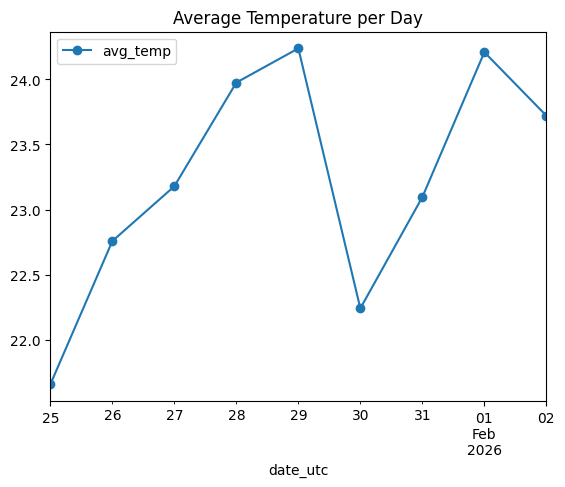

In [4]:
import matplotlib.pyplot as plt

df = con.execute("""
SELECT
  date_utc,
  AVG(temperature_2m) AS avg_temp
FROM weather_hourly
GROUP BY 1
ORDER BY 1;

""").df()

df.plot(x="date_utc", y="avg_temp", marker="o")
plt.title("Average Temperature per Day")
plt.show()
